#  Car price prediction
project plan:
1. prepare data and exploratory data analysis (EDA)
2. Use linear regression for predicting price
3. Understand the internals of linear regression
4. Evaluate the model with RMSE
5. Feature engineering
6. Regularization
7. Use the model

In [2]:
!pip install pandas
!pip install numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

In [4]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [5]:
!wget $data

--2026-06-22 12:20:35--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.01s   

2026-06-22 12:20:36 (127 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



In [6]:
!type wget

wget is /usr/bin/wget


In [7]:
df = pd.read_csv('data.csv')

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [9]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [10]:
df['make'].str.lower().str.replace(' ', '_')

0            bmw
1            bmw
2            bmw
3            bmw
4            bmw
          ...   
11909      acura
11910      acura
11911      acura
11912      acura
11913    lincoln
Name: make, Length: 11914, dtype: str

In [11]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [12]:
strings = list(df.dtypes[df.dtypes == 'string'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [13]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ','_')

In [14]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# 2.3 Exploratory Data Analysis

In [15]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [16]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


distribution of price

In [17]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

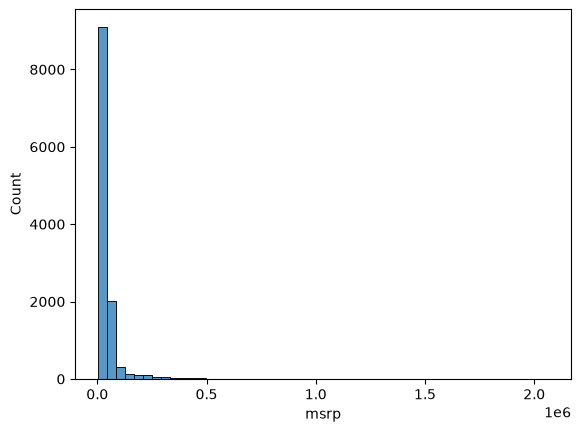

In [19]:
sns.histplot(df.msrp, bins = 50)

<Axes: xlabel='msrp', ylabel='Count'>

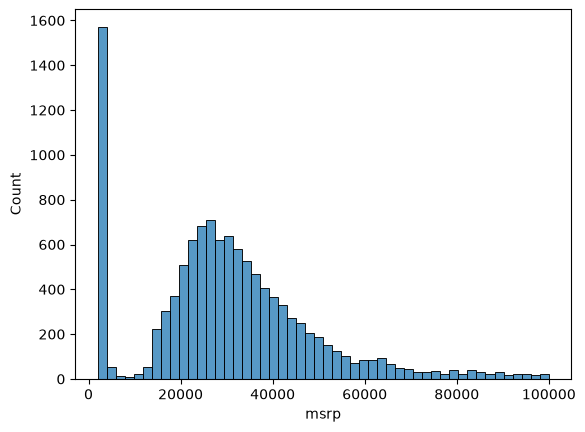

In [20]:
sns.histplot(df.msrp[df.msrp < 10**5], bins = 50)

In [21]:
np.log1p([0,1,10,1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [26]:
np.log([0+1,1+1,10+1,1000+1,100000+1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [27]:
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

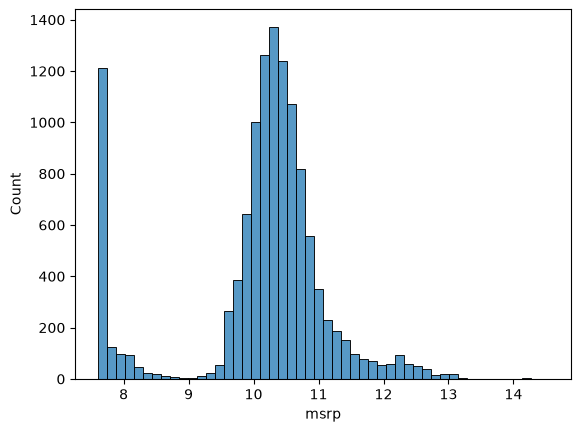

In [28]:
sns.histplot(price_logs, bins = 50)

missing values

In [29]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

setting up the validation framework

In [32]:
n = len(df)

n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

In [33]:
n,n_train, n_val, n_test

(11914, 7150, 2382, 2382)

In [34]:
df.iloc[[10,0,3,5]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10,bmw,1_series,2013,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39600
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200


In [35]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [37]:
idx = np.arange(n)
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [39]:
np.random.seed(2)
np.random.shuffle(idx)
idx

array([ 7077,   982,   142, ..., 11384,  7707,  3163], shape=(11914,))

In [40]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [41]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7077,ford,mustang,2015,premium_unleaded_(recommended),310.0,4.0,manual,rear_wheel_drive,2.0,high-performance,midsize,coupe,31,22,5657,29300
982,mazda,929,1994,regular_unleaded,193.0,6.0,automatic,rear_wheel_drive,4.0,NaN,midsize,sedan,22,17,586,2000
142,bmw,3_series,2015,diesel,180.0,4.0,automatic,all_wheel_drive,4.0,"diesel,luxury",midsize,sedan,43,31,3916,41000
11624,volvo,xc90,2014,regular_unleaded,240.0,6.0,automatic,front_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,25,16,870,42700
8570,nissan,rogue_select,2015,regular_unleaded,170.0,4.0,automatic,all_wheel_drive,4.0,crossover,midsize,4dr_suv,27,22,2009,21500
